<a href="https://colab.research.google.com/github/BagaskaraAdhi/NLP-Ngram-Parsing/blob/main/2318090_Bagaskakra_Adhi_Pradana_NLP_Ngram_Parsing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Instalasi dan Import Library**

In [22]:
!pip install spacy spacy-stanza
import stanza
stanza.download('id')
import nltk
nltk.download('punkt')
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.feature_extraction.text import CountVectorizer
import spacy_stanza
from spacy import displacy
from nltk import CFG, ChartParser, RegexpParser

print("\n[INFO] Semua library dan model Stanza berhasil diinstal!")
print("=" * 60)

INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/stanza_resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/stanza_resources.



[INFO] Semua library dan model Stanza berhasil diinstal!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **2. Mount Google Drive**

In [49]:
drive.mount('/content/drive')

# Mengambil dataset
path = '/content/drive/MyDrive/Text Mining/N-Gram dan Parsing/tokopedia-product-reviews-2019.csv'

try:
    df = pd.read_csv(path)
    print("\n[INFO] Data berhasil dimuat!")

    # Standarisasi kolom (Mengubah 'text' atau 'Review' menjadi 'reviews')
    if 'text' in df.columns:
        df.rename(columns={'text': 'reviews'}, inplace=True)
    elif 'Review' in df.columns:
        df.rename(columns={'Review': 'reviews'}, inplace=True)

    # Membuat label sentimen menggunakan huruf kecil 'rating'
    if 'rating' in df.columns:
        df['label'] = df['rating'].apply(lambda x: 1 if pd.notnull(x) and int(x) > 3 else 0)
    elif 'Rating' in df.columns:
        df['label'] = df['Rating'].apply(lambda x: 1 if pd.notnull(x) and int(x) > 3 else 0)
    # -------------------------

    print("\n--- 5 Baris Pertama Dataset Asli ---")
    display(df.head())
except Exception as e:
    print(f"Terjadi kesalahan saat memuat data: {e}")

# Preprocessing awal: Menghapus data kosong agar tidak error di loop
df = df.dropna(subset=['reviews']).reset_index(drop=True)
print(f"\nBerhasil memuat {len(df)} dokumen ulasan untuk diproses.")
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

[INFO] Data berhasil dimuat!

--- 5 Baris Pertama Dataset Asli ---


,Unnamed: 0,reviews,rating,category,product_name,product_id,sold,shop_id,product_url,label
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - S...,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staple...,1
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...,1
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMB...,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/stap...,1
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; O...,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-stap...,1
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gu...,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-ref...,1



Berhasil memuat 40607 dokumen ulasan untuk diproses.


# **3. Data Preprocessing**

In [50]:
indonesian_stopwords = ["dan", "atau", "yang", "di", "ke", "dari", "pada", "untuk", "akan",
                        "dengan", "itu", "ini", "ada", "tidak", "juga", "adalah", "sebagai",
                        "oleh", "karena", "sehingga", "jika", "maka", "tetapi", "sementara",
                        "setelah", "sebelum", "meskipun", "walaupun", "bahwa", "apabila",
                        "seharusnya", "sebetulnya", "agak", "antara", "begitu", "berapa",
                        "berapapun", "beberapa", "banyak", "cukup", "hampir", "hanya", "ingin",
                        "jangan", "jarang", "juga", "kalau", "kalaupun", "kembali", "kemudian",
                        "kurang", "lebih", "lalu", "lain", "lainnya", "maka", "malah", "memang",
                        "mungkin", "nampak", "nantinya", "nyaris", "pasti", "paling", "perlu",
                        "pernah", "pula", "pun", "saja", "sangat", "sama", "sampai", "sana", "sambil",
                        "sebab", "sebenarnya", "sedang", "sedikit", "sedikitpun", "selalu", "selain",
                        "selama", "seluruh", "sementara", "semua", "sendiri", "seolah", "sepanjang",
                        "sepantasnya", "seperti", "setiap", "sesuatu", "sesudah", "sesungguhnya",
                        "setelah", "setempat", "setengah", "seterusnya", "setidak", "walau", "cukup",
                        "terlalu", "amat", "sangat", "sungguh", "benar", "betul", "pasti", "tentu",
                        "sekali", "sungguh", "teramat", "terlalu", "terbilang", "agak", "sedikit",
                        "banyak", "lebih", "kurang", "hampir", "nyaris", "sekitar", "kira", "sikit",
                        "sedikitnya", "banyaknya", "lebihnya", "kurangnya", "hampirnya", "nyarisnya",
                        "sekitarnya", "kiranya", "lumayan", "cukup", "sudah", "belum", "akan", "ingin",
                        "hendak", "mau", "dapat", "bisa", "boleh", "harus", "perlu", "mesti", "wajib",
                        "patut", "seharusnya", "sebaiknya", "mestinya", "wajibnya", "patutnya", "seharusnya",
                        "mungkin", "barangkali", "agaknya", "rupanya", "sepertinya", "kayaknya", "tampaknya",
                        "terlihat", "ternyata", "nyatanya", "jelas", "jelasnya", "pasti", "tentunya", "tentu",
                        "pastilah", "tentulah", "pasti", "tentu", "pasti", "tentunya"]

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([word for word in text.split() if word not in indonesian_stopwords])
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = ' '.join(text.split())
    return text

df['reviews_clean'] = df['reviews'].apply(clean_text)
print("\n--- Hasil Pembersihan Teks (Preprocessing) ---")
display(df[['reviews', 'reviews_clean']].head())
print("=" * 60)


--- Hasil Pembersihan Teks (Preprocessing) ---


,reviews,reviews_clean
0,Barang sesuai pesanan dan cepat sampai,barang sesuai pesanan cepat
1,Barang bagus harga murah,barang bagus harga murah
2,Paket rapi...mantap....cepat....sampe ke tujuan,paket rapimantapcepatsampe tujuan
3,ya saya puas dgn barangnya,ya saya puas dgn barangnya
4,Responya luar biasa b mantap,responya luar biasa b mantap


# **4. Ekstraksi Fitur N-Gram (Unigram, Bigram, Trigram)**

Ukuran kosakata: 1000
20 item pertama dalam kosakata:
 [('barang', np.int64(77)), ('sesuai', np.int64(825)), ('pesanan', np.int64(677)), ('cepat', np.int64(217)), ('barang sesuai', np.int64(117)), ('sesuai pesanan', np.int64(851)), ('pesanan cepat', np.int64(678)), ('barang sesuai pesanan', np.int64(126)), ('sesuai pesanan cepat', np.int64(852)), ('bagus', np.int64(24)), ('harga', np.int64(384)), ('murah', np.int64(559)), ('barang bagus', np.int64(79)), ('bagus harga', np.int64(33)), ('harga murah', np.int64(385)), ('paket', np.int64(628)), ('tujuan', np.int64(962)), ('ya', np.int64(988)), ('saya', np.int64(783)), ('puas', np.int64(721))]
------------------------------------------------------------

--- 10 UNIGRAM Teratas (1 Kata) ---


,frequency
n_gram,
barang,15282
sesuai,11209
cepat,8412
bagus,7146
pengiriman,4340
baik,4317
terima,4035
respon,3647
gan,3543



--- 10 BIGRAM Teratas (2 Kata) ---


,frequency
n_gram,
barang sesuai,3515
terima kasih,2832
pengiriman cepat,2691
sesuai pesanan,2287
sesuai deskripsi,2262
barang bagus,1894
barang diterima,1372
respon cepat,1265
sesuai gambar,1063



--- 10 TRIGRAM Teratas (3 Kata) ---


,frequency
n_gram,
barang sesuai pesanan,884
barang sesuai deskripsi,767
barang bagus sesuai,414
cepat barang sesuai,366
barang diterima baik,362
terima kasih barang,350
pengiriman cepat barang,324
barang sesuai gambar,305
respon cepat barang,273


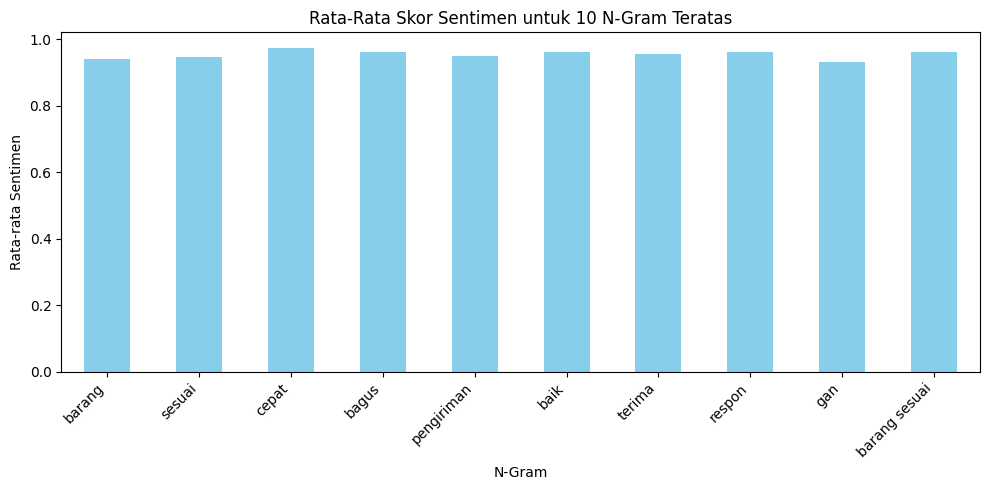

In [51]:
# Inisialisasi CountVectorizer (Rentang 1 sampai 3)
vectorizer = CountVectorizer(ngram_range=(1, 3), max_features=1000, max_df=0.95, min_df=2)
X_ngrams = vectorizer.fit_transform(df['reviews_clean'])

vocabulary = vectorizer.vocabulary_
print("Ukuran kosakata:", len(vocabulary))
print("20 item pertama dalam kosakata:\n", list(vocabulary.items())[:20])
print("-" * 60)
# -------------------------------------------------------------------

# Menghitung frekuensi n-gram
ngram_frequencies = X_ngrams.sum(axis=0)
ngram_df = pd.DataFrame({
    'n_gram': vectorizer.get_feature_names_out(),
    'frequency': ngram_frequencies.tolist()[0]
}).set_index('n_gram')

# Memisahkan Unigram, Bigram, dan Trigram berdasarkan jumlah spasi/kata
ngram_df['word_count'] = ngram_df.index.to_series().apply(lambda x: len(str(x).split()))

unigrams = ngram_df[ngram_df['word_count'] == 1].sort_values('frequency', ascending=False).head(10)
bigrams = ngram_df[ngram_df['word_count'] == 2].sort_values('frequency', ascending=False).head(10)
trigrams = ngram_df[ngram_df['word_count'] == 3].sort_values('frequency', ascending=False).head(10)

print("\n--- 10 UNIGRAM Teratas (1 Kata) ---")
display(unigrams[['frequency']])
print("\n--- 10 BIGRAM Teratas (2 Kata) ---")
display(bigrams[['frequency']])
print("\n--- 10 TRIGRAM Teratas (3 Kata) ---")
display(trigrams[['frequency']])

# Top 10 Campuran
top_10_ngrams = ngram_df.sort_values('frequency', ascending=False).head(10)
top_10_list = top_10_ngrams.index.tolist()

# Visualisasi hubungan n-gram dan sentimen
if 'label' in df.columns:
    sentiment_scores = []
    for ngram in top_10_list:
        reviews_with_ngram = df[df['reviews_clean'].str.contains(ngram, na=False)]
        sentiment_scores.append(reviews_with_ngram['label'].mean() if not reviews_with_ngram.empty else 0)

    sentiment_df = pd.DataFrame({'n_gram': top_10_list, 'average_sentiment': sentiment_scores}).set_index('n_gram')

    plt.figure(figsize=(10, 5))
    sentiment_df['average_sentiment'].plot(kind='bar', color='skyblue')
    plt.title('Rata-Rata Skor Sentimen untuk 10 N-Gram Teratas')
    plt.xlabel('N-Gram')
    plt.ylabel('Rata-rata Sentimen')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
print("=" * 60)

# **5. Constituency Parsing**

In [53]:
import torch

print("\n[INFO] Memuat model Stanza Bahasa Indonesia (Tunggu sebentar)...")

# Patch untuk PyTorch 2.6 di Colab
_original_load = torch.load
def patched_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return _original_load(*args, **kwargs)
torch.load = patched_load

if 'nlp' not in locals():
    nlp = spacy_stanza.load_pipeline("id")

print(f"\n--- Hasil Constituency Parsing untuk 5 N-Gram Teratas ---")
# Membuat aturan otomatis: Frasa Benda (NP) dan Frasa Kerja (VP)
chunk_grammar = """
  NP: {<NOUN|PRON><ADJ|NOUN>*}
  VP: {<ADV>*<VERB><ADV>*<NOUN|ADJ|PRON>*}
"""
chunk_parser = RegexpParser(chunk_grammar)

for i, ngram in enumerate(top_10_list[:5], 1):
    matching_reviews = df[df['reviews_clean'].str.contains(ngram, na=False)]['reviews_clean'].tolist()
    if matching_reviews:
        sample_review = min(matching_reviews, key=len)
        print(f"\n[{i}] Kata Kunci N-Gram : '{ngram}'")
        print(f"    Ulasan Terkait    : '{sample_review}'")

        # POS Tagging dengan Stanza
        doc = nlp(sample_review)
        pos_tags = [(token.text, token.pos_) for token in doc]

        print(f"    POS Tags          : {pos_tags}")

        # Membuat pohon (Tree)
        tree = chunk_parser.parse(pos_tags)

        print(f"    Struktur Bracket  : {tree}")

        # Mencetak pohon ASCII
        print("    Pohon Sintaksis (ASCII) :")
        tree.pretty_print()
    print("-" * 60)


[INFO] Memuat model Stanza Bahasa Indonesia (Tunggu sebentar)...

--- Hasil Constituency Parsing untuk 5 N-Gram Teratas ---

[1] Kata Kunci N-Gram : 'barang'
    Ulasan Terkait    : 'barang'
    POS Tags          : [('barang', 'NOUN')]
    Struktur Bracket  : (S (NP barang/NOUN))
    Pohon Sintaksis (ASCII) :
     S     
     |      
     NP    
     |      
barang/NOUN

------------------------------------------------------------

[2] Kata Kunci N-Gram : 'sesuai'
    Ulasan Terkait    : 'sesuai'
    POS Tags          : [('sesuai', 'ADJ')]
    Struktur Bracket  : (S sesuai/ADJ)
    Pohon Sintaksis (ASCII) :
    S     
    |      
sesuai/ADJ

------------------------------------------------------------

[3] Kata Kunci N-Gram : 'cepat'
    Ulasan Terkait    : 'cepat'
    POS Tags          : [('cepat', 'ADJ')]
    Struktur Bracket  : (S cepat/ADJ)
    Pohon Sintaksis (ASCII) :
    S    
    |     
cepat/ADJ

------------------------------------------------------------

[4] Kata Kunci N-G

# **6. Dependency Parsing**

In [60]:
from IPython.display import display, HTML

dep_dict = {
    "root"    : "aksi utama",        "nsubj"   : "pelaku",
    "obj"     : "objek",             "dobj"    : "korban",
    "amod"    : "penjelas sifat",    "advmod"  : "keterangan",
    "obl"     : "keterangan pelengkap", "case" : "kata depan/penanda",
    "cc"      : "kata hubung",       "conj"    : "kalimat setara",
    "compound": "kata majemuk",      "flat"    : "frasa majemuk",
    "det"     : "penentu",           "mark"    : "penanda",
    "nmod"    : "penjelas benda",    "punct"   : "tanda baca"
}

# ── Fungsi pohon ASCII dependency ──────────────────────────────────────────
def build_tree_lines(token, dep_dict, prefix="", is_last=True, is_root=False):
    """
    Rekursif membangun pohon ASCII dependency.
    Contoh:
        menggigit (root: aksi utama)
        ├── Anjing (nsubj: pelaku)
        └── pria (dobj: korban)
            └── tongkat (with: alat)
    """
    label     = dep_dict.get(token.dep_.lower(), token.dep_)
    connector = "" if is_root else ("└── " if is_last else "├── ")
    line      = f"{prefix}{connector}{token.text} ({token.dep_}: {label})"
    lines     = [line]

    children     = list(token.children)
    child_prefix = "" if is_root else (prefix + ("    " if is_last else "│   "))

    for j, child in enumerate(children):
        lines += build_tree_lines(
            child, dep_dict,
            prefix=child_prefix,
            is_last=(j == len(children) - 1)
        )
    return lines


def print_dep_tree(doc, dep_dict):
    """Cetak pohon dependency mulai dari token ROOT."""
    root_token = next((t for t in doc if t.dep_ == "root"), None)

    if root_token is None:
        print("  (tidak ada token ROOT ditemukan)")
        return

    for line in build_tree_lines(root_token, dep_dict, is_root=True):
        print(line)

# ── Loop dependency parsing ─────────────────────────────────────────────────
print("\n--- Hasil Dependency Parsing untuk 5 N-Gram Teratas ---")

for i, ngram in enumerate(top_10_list[:5], 1):
    matching_reviews = df[df['reviews_clean'].str.contains(ngram, na=False)]['reviews_clean'].tolist()
    if not matching_reviews:
        continue
    long_reviews = [r for r in matching_reviews if len(r.split()) >= 4]

    if not long_reviews:
        long_reviews = [r for r in matching_reviews if len(r.split()) >= 2]

    if not long_reviews:
        long_reviews = matching_reviews

    sample_review = min(long_reviews, key=len)

    print(f"\n[{i}] Kalimat (Kata Kunci N-Gram '{ngram}'):")
    print(f"     '{sample_review}'")

    doc_dep = nlp(sample_review)

    # Tabel relasi
    dep_data = []
    for token in doc_dep:
        dep_data.append({
            "Token (Kata)"       : token.text,
            "Relasi (Dependency)": token.dep_,
            "Induk (Head)"       : token.head.text,
            "Penjelasan Relasi"  : dep_dict.get(token.dep_.lower(), "relasi lainnya")
        })

    display(pd.DataFrame(dep_data))

    # Pohon ASCII
    print("\n  Pohon Dependency:")
    print_dep_tree(doc_dep, dep_dict)
    print("-" * 60)

# ── Visualisasi graf displacy untuk N-Gram peringkat 1 ─────────────────────
print("\n[INFO] Visualisasi Graf Dependency (N-Gram Peringkat 1):")

best_ngram           = top_10_list[0]
matching_reviews_dep = df[df['reviews_clean'].str.contains(best_ngram, na=False)]['reviews_clean'].tolist()

# Pilih kalimat dengan minimal 4 kata agar graf tidak kosong
long_reviews_dep = [r for r in matching_reviews_dep if len(r.split()) >= 4]
if not long_reviews_dep:
    long_reviews_dep = [r for r in matching_reviews_dep if len(r.split()) >= 2]
if not long_reviews_dep:
    long_reviews_dep = matching_reviews_dep

final_sentence = min(long_reviews_dep, key=len) if long_reviews_dep else "pengiriman barang sangat cepat"

print(f"  Kalimat : '{final_sentence}'")

doc_final  = nlp(final_sentence)
html_graph = displacy.render(
    doc_final, style="dep", jupyter=False,
    options={'distance': 110, 'color': '#1f77b4', 'bg': '#ffffff'}
)
display(HTML(html_graph))



--- Hasil Dependency Parsing untuk 5 N-Gram Teratas ---

[1] Kalimat (Kata Kunci N-Gram 'barang'):
     'barang gan tq gan'


,Token (Kata),Relasi (Dependency),Induk (Head),Penjelasan Relasi
0,barang,root,barang,aksi utama
1,gan,compound,barang,kata majemuk
2,tq,nmod,gan,penjelas benda
3,gan,flat:name,tq,relasi lainnya



  Pohon Dependency:
barang (root: aksi utama)
└── gan (compound: kata majemuk)
    └── tq (nmod: penjelas benda)
        └── gan (flat:name: flat:name)
------------------------------------------------------------

[2] Kalimat (Kata Kunci N-Gram 'sesuai'):
     'cepat 1 hr sesuai'


,Token (Kata),Relasi (Dependency),Induk (Head),Penjelasan Relasi
0,cepat,root,cepat,aksi utama
1,1,nummod,hr,relasi lainnya
2,hr,compound,cepat,kata majemuk
3,sesuai,amod,hr,penjelas sifat



  Pohon Dependency:
cepat (root: aksi utama)
└── hr (compound: kata majemuk)
    ├── 1 (nummod: nummod)
    └── sesuai (amod: penjelas sifat)
------------------------------------------------------------

[3] Kalimat (Kata Kunci N-Gram 'cepat'):
     'cepat 1 hr sesuai'


...


  Pohon Dependency:
cepat (root: aksi utama)
└── hr (compound: kata majemuk)
    ├── 1 (nummod: nummod)
    └── sesuai (amod: penjelas sifat)
------------------------------------------------------------

[4] Kalimat (Kata Kunci N-Gram 'bagus'):
     'bagus n lucu suka'


,Token (Kata),Relasi (Dependency),Induk (Head),Penjelasan Relasi
0,bagus,amod,suka,penjelas sifat
1,n,nsubj,suka,pelaku
2,lucu,amod,n,penjelas sifat
3,suka,root,suka,aksi utama



  Pohon Dependency:
suka (root: aksi utama)
├── bagus (amod: penjelas sifat)
└── n (nsubj: pelaku)
    └── lucu (amod: penjelas sifat)
------------------------------------------------------------

[5] Kalimat (Kata Kunci N-Gram 'pengiriman'):
     'pengiriman ok barang ok'


,Token (Kata),Relasi (Dependency),Induk (Head),Penjelasan Relasi
0,pengiriman,root,pengiriman,aksi utama
1,ok,compound,pengiriman,kata majemuk
2,barang,compound,ok,kata majemuk
3,ok,compound,barang,kata majemuk



  Pohon Dependency:
pengiriman (root: aksi utama)
└── ok (compound: kata majemuk)
    └── barang (compound: kata majemuk)
        └── ok (compound: kata majemuk)
------------------------------------------------------------

[INFO] Visualisasi Graf Dependency (N-Gram Peringkat 1):
  Kalimat : 'barang gan tq gan'
